# EDA Visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_churn.csv")

df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


In [3]:
df.shape

(5020, 14)

In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'TenureYears', 'MonthlyCharges',
       'TotalCharges', 'ContractType', 'InternetService', 'PaymentMethod',
       'SeniorCitizen', 'SupportCalls', 'StreamingService', 'PaperlessBilling',
       'Churn'],
      dtype='str')

In [6]:
df.dtypes

CustomerID              str
Age                 float64
Gender                  str
TenureYears           int64
MonthlyCharges      float64
TotalCharges        float64
ContractType            str
InternetService         str
PaymentMethod           str
SeniorCitizen           str
SupportCalls          int64
StreamingService        str
PaperlessBilling        str
Churn                   str
dtype: object

### 1. Histogram

A histogram shows the distribution of a numerical variable by dividing values into intervals called bins.

It helps us understand:

* Where most values occur
* Whether the distribution is symmetric
* Whether it is skewed
* Whether there are unusual values
  
Example:

Suppose a telecom company wants to understand customer tenure.

A histogram can answer:

"Are most customers new customers or long-term customers?"

#### AI/ML usage

Histograms are useful before ML because they help identify:

* Skewed features
* Extreme values
* Distribution shape
* Potential transformations

Why use it?

When dataset contains numerical variables such as:

* Age
* TenureYears
* MonthlyCharges
* TotalCharges

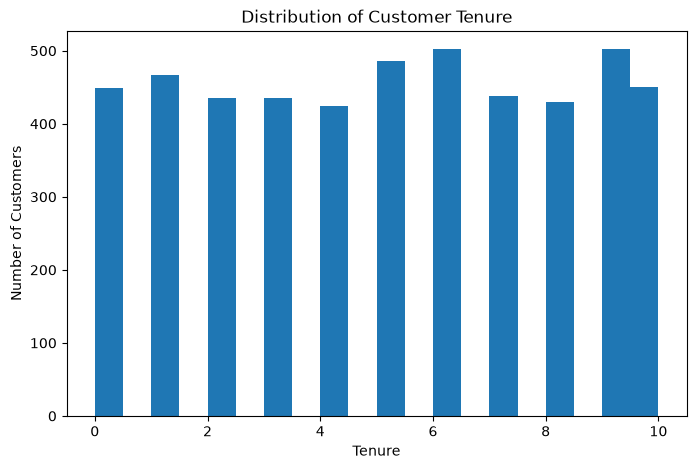

In [8]:
# Analysing Tenure

plt.figure(figsize=(8, 5))

plt.hist(df["TenureYears"], bins=20)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")

plt.show()

The histogram helps us understand the distribution of customer tenure and whether customers are concentrated in particular tenure ranges.

### 2. Box Plot

A box plot displays the distribution of numerical data using:

* Minimum
* Q1
* Median
* Q3
* Maximum
* Potential outliers

Example:

A company may want to identify customers with unusually high monthly charges.

A box plot can show those unusual customers.

#### AI/ML usage

Box plots are important for:

* Outlier detection
* Understanding spread
* Comparing distributions
* Identifying potentially problematic observations


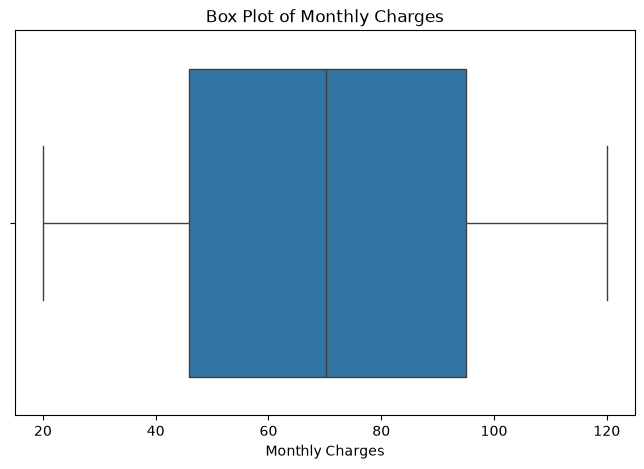

In [9]:
# Analysing MonthlyCharges

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MonthlyCharges"])

plt.title("Box Plot of Monthly Charges")
plt.xlabel("Monthly Charges")

plt.show()

* The box represents the middle 50% of customers.
* Points outside the whiskers may represent potential outliers.
* The box plot helps identify the typical range of monthly charges and potential customers with unusually high or low charges.

### 3. Bar Chart

A bar chart compares values across categories.

Example:

A telecom company might want to know how many customers use each type of internet service.

For example:

* DSL
* Fiber optic
* No internet

#### AI/ML usage

Bar charts help understand categorical features before encoding them for ML.

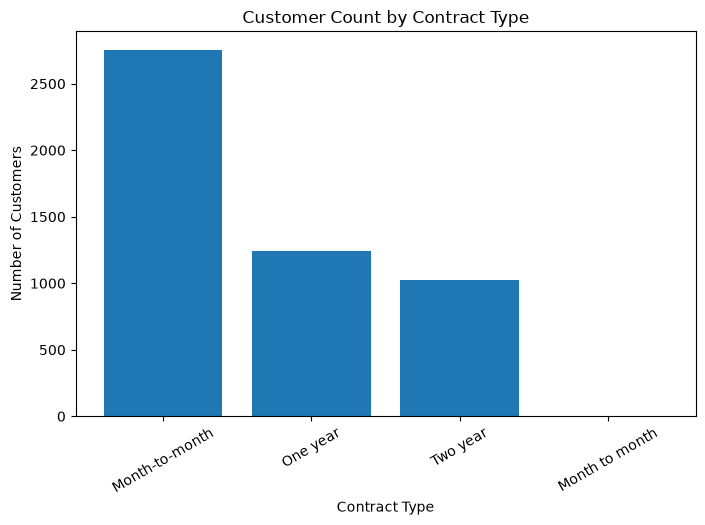

In [11]:
# Analysing contract

contract_counts = df["ContractType"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    contract_counts.index,
    contract_counts.values
)

plt.title("Customer Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

* The height of each bar represents the number of customers in that contract category.
* The visualization shows which contract types are most common among customers.

### 4. Count Plot

A count plot is specifically designed to display the number of observations in each category.

It is similar to a bar chart, but Seaborn automatically calculates the category counts.

Example:

A company wants to know:

"How many customers churned versus stayed?"

#### AI/ML usage

Count plots are particularly useful for:

* Target distribution
* Categorical feature analysis
* Class imbalance

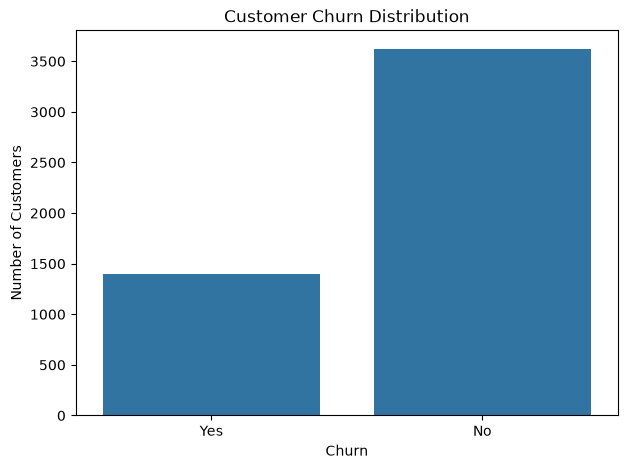

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

The No class is larger than the Yes class, indicating moderate class imbalance. This should be considered when evaluating the Machine Learning model.

### 5. Count Plot – Churn by Contract

This is much more meaningful than simply plotting the contract distribution.

Why:

Does churn vary according to contract type?

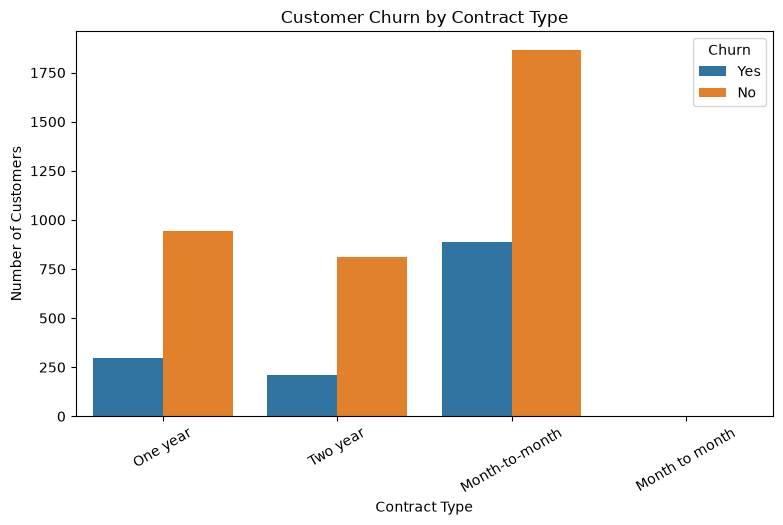

In [15]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="ContractType",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

* This visualization allows us to compare churn behavior across contract types and identify whether certain contract categories have more churn.
* This type of visualization is much more useful for EDA because it examines the relationship between a feature and the target.

### 6. Scatter Plot

A scatter plot shows the relationship between two numerical variables.

Each point represents one observation.

Example:

A telecom company might ask:

"Do customers with longer tenure tend to have higher total charges?"

We can compare:

Tenure vs TotalCharges

#### AI/ML usage

Scatter plots help identify:

* Relationships
* Positive correlation
* Negative correlation
* Non-linear relationships
* Clusters
* Outliers
  
Why use it?

Tenure and TotalCharges are both numerical.

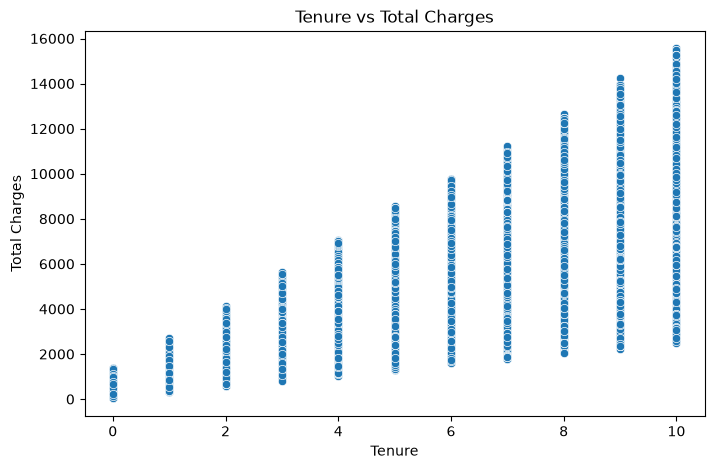

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TenureYears",
    y="TotalCharges"
)

plt.title("Tenure vs Total Charges")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")

plt.show()

* Customers with longer tenure generally tend to accumulate higher total charges.

### 7. Scatter Plot with Churn

We can make the scatter plot more useful by adding the target.

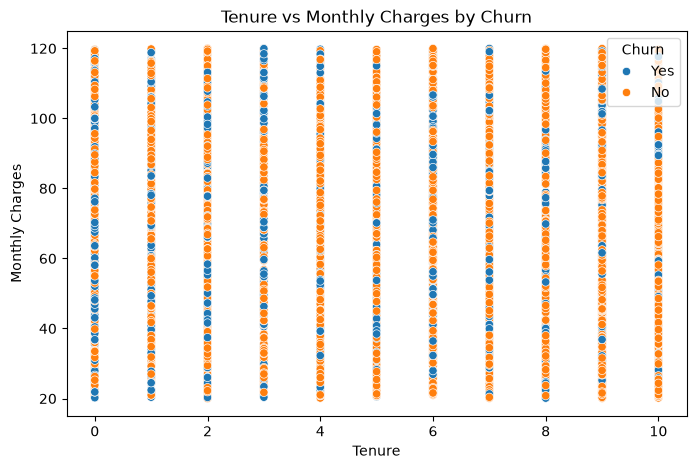

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TenureYears",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

* This visualization helps determine whether combinations of tenure and monthly charges show visible differences between churned and retained customers.

### 8. Line Plot
A line plot connects values using lines and is primarily useful for showing trends across an ordered variable, especially time.

Example:

A company might track:

Month → Number of customers

to understand whether churn is increasing over time.

#### AI/ML usage

Line plots can help identify:

* Trends
* Seasonality
* Time-based patterns
* Changes over ordered values
  
Important points:

The churn dataset does not appear to be a true time-series dataset.

Therefore, we should not randomly use a line plot.

Instead, we can use an ordered variable such as Tenure to examine average churn rate by tenure.

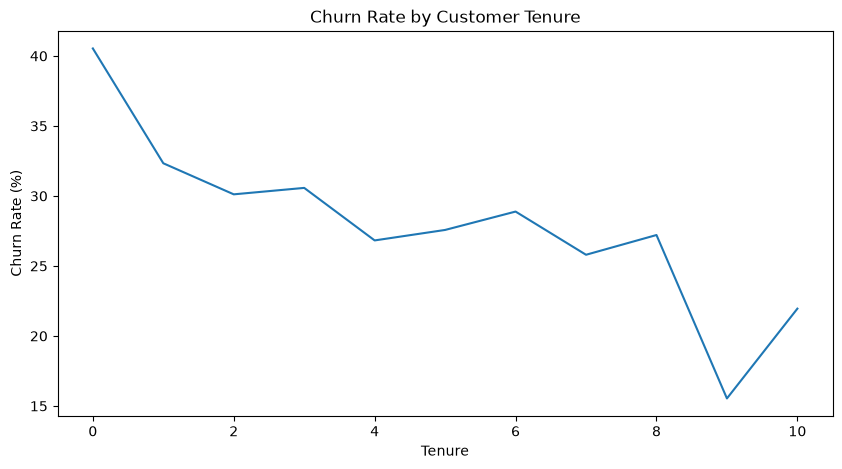

In [21]:
churn_by_tenure = (
    df.groupby("TenureYears")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    churn_by_tenure.index,
    churn_by_tenure.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")

plt.show()

* This can reveal whether churn is concentrated among newer customers or longer-tenure customers.

### 9. Violin Plot

A violin plot combines characteristics of a box plot with a density distribution.

It shows:

* Median
* Spread
* Distribution shape
* Density

Example:

A telecom company wants to compare:

"How are monthly charges distributed between customers who churn and customers who stay?"

#### AI/ML usage

Violin plots help identify whether a numerical feature has different distributions across target classes.

This can help with feature analysis for classification.

Why use it?

To Compare: MonthlyCharges vs Churn

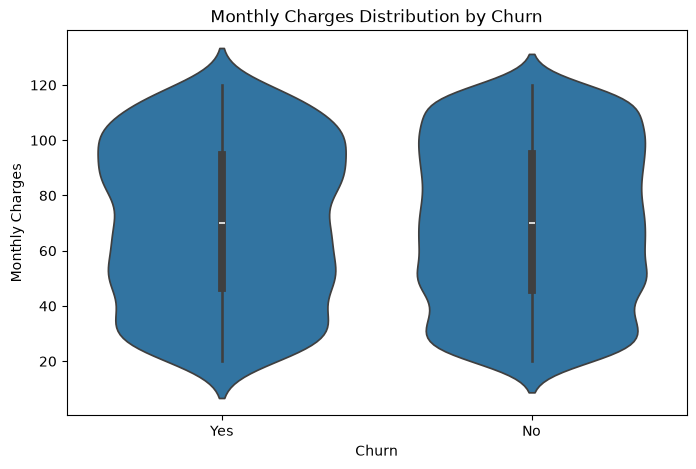

In [22]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

* The violin plot helps determine whether the distribution of monthly charges differs between customers who churn and those who stay.

### 10. Pair Plot

A pair plot simultaneously shows relationships between multiple numerical variables.

It creates:

* Scatter plots between variables
* Distribution plots along the diagonal

Example:

A business may want to examine relationships among:

* Age
* Tenure
* MonthlyCharges
* TotalCharges

#### AI/ML usage

Pair plots help with:

* Feature relationship analysis
* Correlation exploration
* Detecting clusters
* Detecting possible outliers
* Understanding relationships before modeling

Important note:

* Do not use every numerical column if the dataset has many variables because the plot can become cluttered.
* Choose a few important numerical features.

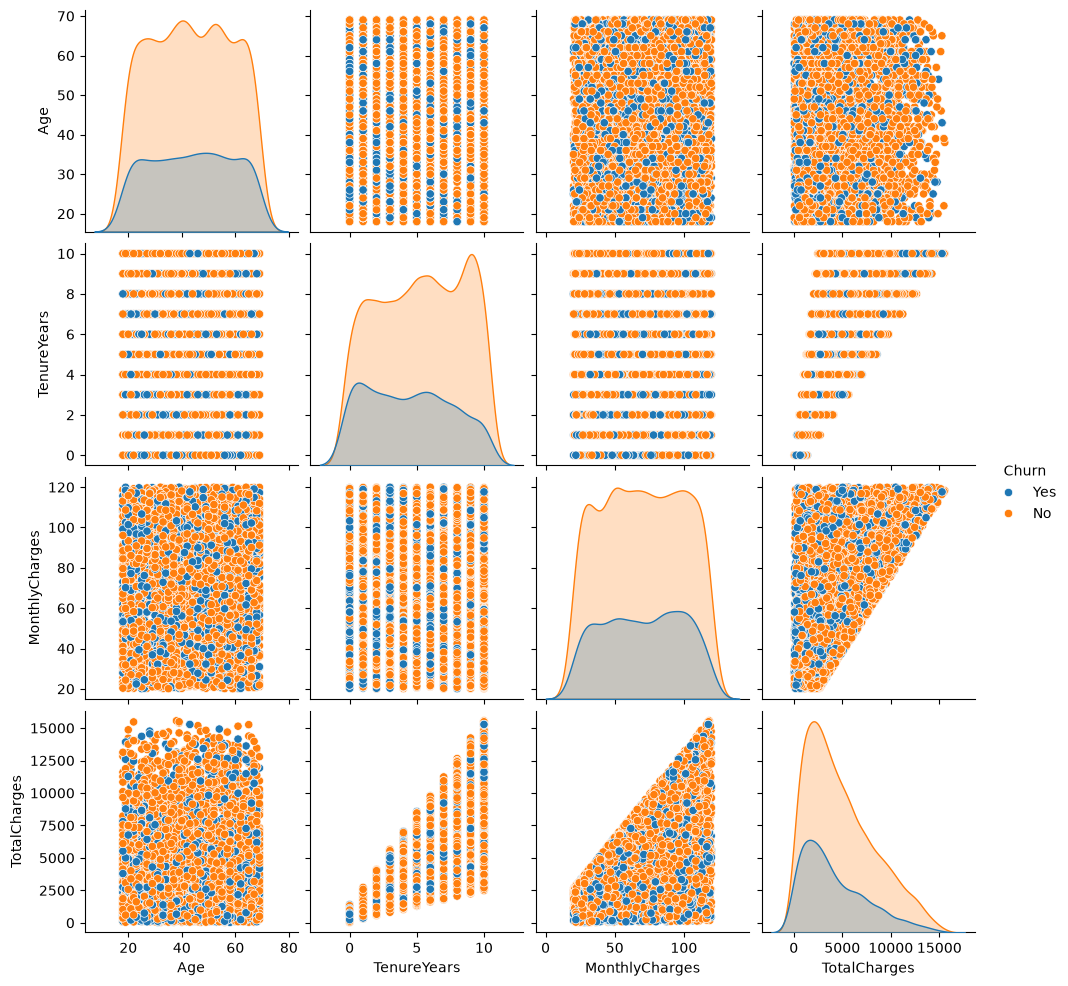

In [26]:
numerical_features = [
    "Age",
    "TenureYears",
    "MonthlyCharges",
    "TotalCharges"
]
sns.pairplot(
    df[numerical_features + ["Churn"]],
    hue="Churn"
)

plt.show()


* The pair plot provides an overall view of relationships among numerical features and can reveal whether churn classes occupy different regions of the feature space.

### 11. Heatmap

A heatmap represents numerical values using different levels of visual intensity.

In EDA, one of the most common uses is displaying a correlation matrix.

Example:

A company wants to know:

"Which numerical variables are strongly related to each other?"

#### AI/ML usage

Correlation heatmaps help identify:

* Strong relationships
* Redundant features
* Potential multicollinearity
* Features that may require further investigation

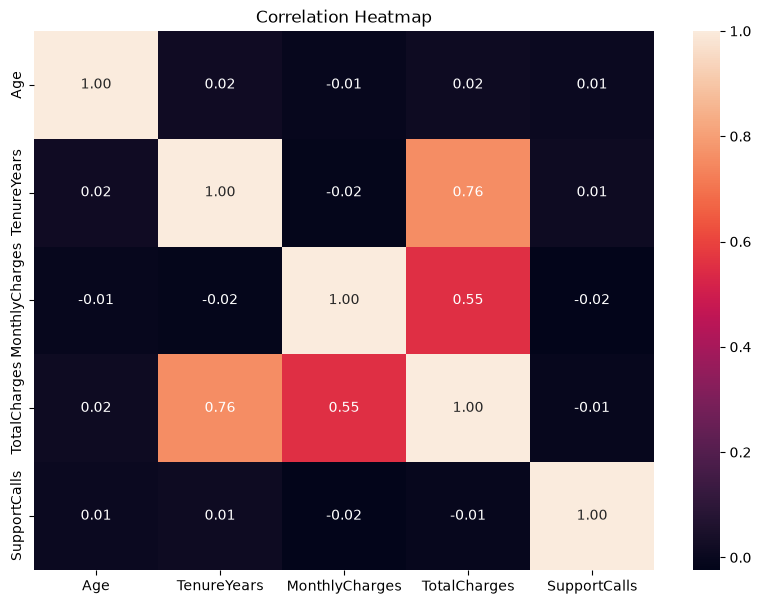

In [27]:
numerical_df = df.select_dtypes(include="number")

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Correlation values range from:

* -1 → Strong negative relationship
* 0 → No linear relationship
* +1 → Strong positive relationship

### 12. Distribution Plot

A distribution plot shows how numerical values are distributed.

Seaborn's histplot() can display a histogram with a KDE curve.

Example:

A company wants to understand the distribution of:

Monthly Charges

#### AI/ML usage

Distribution plots help identify:

* Central tendency
* Spread
* Skewness
* Multiple peaks
* Potential unusual values

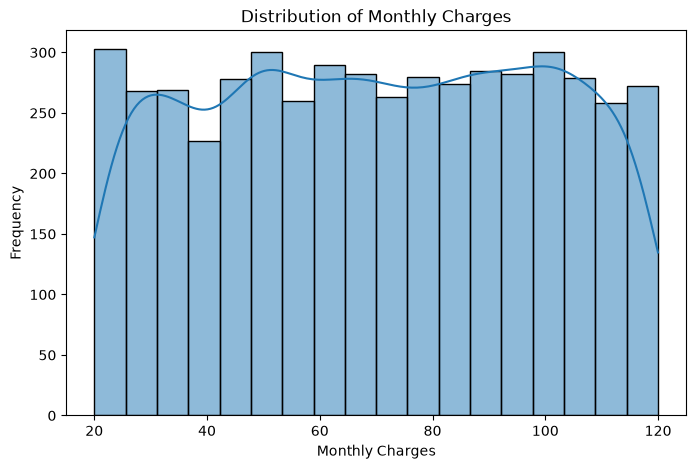

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

* The bars show the frequency and the KDE curve provides a smoothed representation of the distribution.
* The distribution plot helps understand the typical monthly charge range and whether the variable is approximately symmetric or skewed.